<a id="top"></a>
<div style="
    background: linear-gradient(135deg, #0f172a 0%, #1e3a5f 50%, #0f4c75 100%);
    border-radius: 18px;
    padding: 52px 40px 44px 40px;
    text-align: center;
    box-shadow: 0 10px 40px rgba(0,0,0,0.4);
    border: 1px solid rgba(255,255,255,0.08);
    margin-bottom: 8px;
">
    <p style="margin:0 0 10px 0; font-size:11px; letter-spacing:4px;
              text-transform:uppercase; color:#94a3b8;
              font-family:'Segoe UI',sans-serif; font-weight:600;">
        Natural Language Processing · Terminology · Python
    </p>
    <h1 style="margin:0 0 16px 0; font-size:38px; font-weight:800; color:#f1f5f9;
               font-family:'Segoe UI',sans-serif; text-shadow:0 2px 8px rgba(0,0,0,0.5);
               letter-spacing:0.5px; line-height:1.2;">
        Automatic Term Extraction<br>from Scratch
    </h1>
    <p style="margin:0 0 28px 0; font-size:16px; color:#94a3b8;
              font-family:'Segoe UI',sans-serif;">
        Building the C-value algorithm and a complete ATE pipeline in pure Python —<br>
        with error analysis, benchmark context, and a decision guide.
    </p>
    <div style="display:inline-flex; gap:10px; flex-wrap:wrap; justify-content:center;">
        <span style="background:rgba(20,184,166,0.2); color:#5eead4; padding:5px 14px;
                     border-radius:20px; font-size:13px; font-family:'Segoe UI',sans-serif;">Zero dependencies</span>
        <span style="background:rgba(37,99,235,0.2); color:#93c5fd; padding:5px 14px;
                     border-radius:20px; font-size:13px; font-family:'Segoe UI',sans-serif;">C-value · Weirdness</span>
        <span style="background:rgba(225,166,36,0.2); color:#fcd34d; padding:5px 14px;
                     border-radius:20px; font-size:13px; font-family:'Segoe UI',sans-serif;">ACTER benchmark</span>
        <span style="background:rgba(142,68,173,0.25); color:#d8b4fe; padding:5px 14px;
                     border-radius:20px; font-size:13px; font-family:'Segoe UI',sans-serif;">LLM comparison</span>
    </div>
</div>

[![Python](https://img.shields.io/badge/Python-3.8+-3776AB?logo=python&logoColor=white)](https://www.python.org/)
[![Dependencies](https://img.shields.io/badge/core%20pipeline-zero%20dependencies-2ECC40)](https://github.com/huseyincenik/automatic_term_extraction)
[![Kaggle](https://img.shields.io/badge/Kaggle-Notebook-20BEFF?logo=kaggle&logoColor=white)](https://www.kaggle.com/code/huseyincenik/automatic-term-extraction)
[![GitHub](https://img.shields.io/badge/GitHub-Repository-181717?logo=github&logoColor=white)](https://github.com/huseyincenik/automatic_term_extraction)
[![Licence](https://img.shields.io/badge/Code-MIT-green)](https://github.com/huseyincenik/automatic_term_extraction)

<ul class="nav flex-column" style="font-family:'Segoe UI',sans-serif;">
  <h3 class="list-group-item list-group-item-action active" data-toggle="list" role="tab"
      style="background-color:#2563eb; color:white; border-radius:8px; padding:10px 16px;">
      <b>🔤 Automatic Term Extraction from Scratch</b></h3>
  <li class="nav-item"><a class="nav-link" style="color:#2563eb"
      href="https://www.kaggle.com/code/huseyincenik/automatic-term-extraction"><b>Kaggle Notebook — this notebook</b></a></li>
  <li class="nav-item"><a class="nav-link" style="color:red"
      href="https://github.com/huseyincenik/automatic_term_extraction"><b>GitHub Repository — code, figures and research notes</b></a></li>
  <li class="nav-item"><a class="nav-link" style="color:green"
      href="https://www.linkedin.com/in/huseyincenik/"><b>My LinkedIn Account</b></a></li>
</ul>

### 🔗 Project resources

| Resource | Link | Contents |
|---|---|---|
| **Kaggle Notebook** | [automatic-term-extraction](https://www.kaggle.com/code/huseyincenik/automatic-term-extraction) | This notebook — the runnable pipeline |
| **GitHub Repository** | [automatic_term_extraction](https://github.com/huseyincenik/automatic_term_extraction) | Source, article figures, and the research dossier |
| **ACTER dataset** | [AylaRT/ACTER](https://github.com/AylaRT/ACTER) | The benchmark referenced throughout (CC BY-NC-SA 4.0) |
| **PyATE** | [kevinlu1248/pyate](https://github.com/kevinlu1248/pyate) | Production library implementing C-value and four other algorithms |

### 📌 About this notebook

This notebook is the **executable companion** to the article
*"Automatic Term Extraction: The Research Field Behind Your Keyword Extractor."*
Everything the article claims about the pipeline is computed here, in order,
with no hidden steps — the tables printed below are the tables in the article.

| Part | Section | What it covers |
|---|---|---|
| I | [1 · Terms Are Not Keywords](#s1) | Why ATE is a distinct task, and the ACTER annotation scheme |
| I | [2 · The Canonical Pipeline](#s2) | The hybrid linguistic + statistical architecture |
| II | [3 · Candidate Generation](#s3) | The linguistic filter, and a dependency-free approximation |
| II | [4 · C-value](#s4) | The nested-term problem, derived and implemented |
| II | [5 · Weirdness](#s5) | Contrastive scoring against a general corpus |
| II | [6 · The Full Pipeline](#s6) | Combining unithood and termhood |
| III | [7 · Use Case: A Wind-Energy Termbase](#s7) | Running it, and reading the output |
| III | [8 · Error Analysis](#s8) | Where it fails, and why that matters |
| IV | [9 · Evaluation & the ACTER Benchmark](#s9) | How ATE systems are actually compared |
| IV | [10 · The State of the Art](#s10) | Feature engineering → Transformers → LLMs |
| IV | [11 · Choosing a Method](#s11) | A decision guide |
| — | [12 · References](#s12) | Every paper cited |

> **Reproducibility.** Sections 3–8 depend on nothing outside the Python
> standard library. `pandas` and `matplotlib` are used for display only, and
> both ship with Kaggle by default.

<a id="toc"></a>
<div style="background:#1e293b; border-radius:12px; padding:26px 34px;
            border:1px solid #334155; font-family:'Segoe UI',sans-serif;">
  <h2 style="color:#f1f5f9; margin:0 0 18px 0; font-size:20px;
             border-bottom:2px solid #334155; padding-bottom:12px;">📋 Table of Contents</h2>
  <div style="display:grid; grid-template-columns:1fr 1fr; gap:6px 30px;">
    <div>
      <p style="color:#94a3b8; font-size:12px; text-transform:uppercase; letter-spacing:2px;
                margin:12px 0 6px 0; font-weight:700;">Part I · The Task</p>
      <ul style="list-style:none; padding:0; margin:0; color:#cbd5e1; font-size:14px; line-height:2;">
        <li><a href="#s1" style="color:#60a5fa; text-decoration:none;">1 · Terms Are Not Keywords</a></li>
        <li><a href="#s2" style="color:#60a5fa; text-decoration:none;">2 · The Canonical Pipeline</a></li>
      </ul>
      <p style="color:#94a3b8; font-size:12px; text-transform:uppercase; letter-spacing:2px;
                margin:16px 0 6px 0; font-weight:700;">Part II · Building It</p>
      <ul style="list-style:none; padding:0; margin:0; color:#cbd5e1; font-size:14px; line-height:2;">
        <li><a href="#s3" style="color:#60a5fa; text-decoration:none;">3 · Candidate Generation</a></li>
        <li><a href="#s4" style="color:#60a5fa; text-decoration:none;">4 · C-value</a></li>
        <li><a href="#s5" style="color:#60a5fa; text-decoration:none;">5 · Weirdness</a></li>
        <li><a href="#s6" style="color:#60a5fa; text-decoration:none;">6 · The Full Pipeline</a></li>
      </ul>
    </div>
    <div>
      <p style="color:#94a3b8; font-size:12px; text-transform:uppercase; letter-spacing:2px;
                margin:12px 0 6px 0; font-weight:700;">Part III · Results</p>
      <ul style="list-style:none; padding:0; margin:0; color:#cbd5e1; font-size:14px; line-height:2;">
        <li><a href="#s7" style="color:#60a5fa; text-decoration:none;">7 · Use Case: Wind-Energy Termbase</a></li>
        <li><a href="#s8" style="color:#60a5fa; text-decoration:none;">8 · Error Analysis</a></li>
      </ul>
      <p style="color:#94a3b8; font-size:12px; text-transform:uppercase; letter-spacing:2px;
                margin:16px 0 6px 0; font-weight:700;">Part IV · The Field</p>
      <ul style="list-style:none; padding:0; margin:0; color:#cbd5e1; font-size:14px; line-height:2;">
        <li><a href="#s9" style="color:#60a5fa; text-decoration:none;">9 · Evaluation & ACTER</a></li>
        <li><a href="#s10" style="color:#60a5fa; text-decoration:none;">10 · The State of the Art</a></li>
        <li><a href="#s11" style="color:#60a5fa; text-decoration:none;">11 · Choosing a Method</a></li>
        <li><a href="#s12" style="color:#60a5fa; text-decoration:none;">12 · References</a></li>
      </ul>
    </div>
  </div>
</div>

<a id="s1"></a>
<div style="
    background: linear-gradient(90deg, #0f172a 0%, #2563eb 55%, #0f172a 100%);
    border-radius: 12px;
    padding: 18px 28px;
    margin: 34px 0 6px 0;
    box-shadow: 0 4px 14px rgba(0,0,0,0.25);
">
<h2 style="margin:0; font-size:23px; font-weight:800; color:#f1f5f9;
           font-family:'Segoe UI',sans-serif; letter-spacing:0.3px;">
1 &nbsp;Terms Are Not Keywords</h2>
<p style="margin:8px 0 0 0; font-size:14px; color:#94a3b8; font-family:'Segoe UI',sans-serif;">The distinction is not pedantic — it determines the entire system design.</p>
</div>

<p style="text-align:right; margin-top:6px;"><a href="#toc"
   style="color:#2563eb; text-decoration:none; font-size:13px;">back to top ↑</a></p>

**Keyword extraction** operates on a single document and asks: *which words best
summarise this text?* The reference point is the document itself.

**Term extraction** operates on a domain corpus and asks: *which expressions constitute
the specialised vocabulary of this field?* The reference point is general language.
A term such as *doubly fed induction generator* is a term regardless of which
wind-energy document it appears in, and regardless of whether it summarises that document.

Automatic Term Extraction (ATE) is, in the words of the field's most recent survey,
"a Natural Language Processing (NLP) task intended to automatically identify specialized
terms present in domain-specific corpora," where terms function "as units of knowledge in
a specific field of expertise" (Tran et al., 2026).

<table style="width:100%; border-collapse:collapse; font-family:'Segoe UI',sans-serif; font-size:14px;">
  <thead>
    <tr style="background:#0f172a; color:white;">
      <th style="padding:11px 14px; text-align:left;">Dimension</th>
      <th style="padding:11px 14px; text-align:left;">Keyword extraction</th>
      <th style="padding:11px 14px; text-align:left;">Automatic term extraction</th>
    </tr>
  </thead>
  <tbody>
    <tr style="background:#f8fafc;">
      <td style="padding:9px 14px; border-bottom:1px solid #e2e8f0;"><b>Question answered</b></td>
      <td style="padding:9px 14px; border-bottom:1px solid #e2e8f0;">What is this document about?</td>
      <td style="padding:9px 14px; border-bottom:1px solid #e2e8f0;">What vocabulary defines this domain?</td></tr>
    <tr>
      <td style="padding:9px 14px; border-bottom:1px solid #e2e8f0;"><b>Unit of analysis</b></td>
      <td style="padding:9px 14px; border-bottom:1px solid #e2e8f0;">A single document</td>
      <td style="padding:9px 14px; border-bottom:1px solid #e2e8f0;">A domain corpus</td></tr>
    <tr style="background:#f8fafc;">
      <td style="padding:9px 14px; border-bottom:1px solid #e2e8f0;"><b>Candidate generation</b></td>
      <td style="padding:9px 14px; border-bottom:1px solid #e2e8f0;">All n-grams, or stopword-delimited chunks</td>
      <td style="padding:9px 14px; border-bottom:1px solid #e2e8f0;">POS-constrained patterns, e.g. (ADJ|NOUN)+ NOUN</td></tr>
    <tr>
      <td style="padding:9px 14px; border-bottom:1px solid #e2e8f0;"><b>Ranking signal</b></td>
      <td style="padding:9px 14px; border-bottom:1px solid #e2e8f0;">TF-IDF, TextRank, YAKE, KeyBERT</td>
      <td style="padding:9px 14px; border-bottom:1px solid #e2e8f0;">C-value, weirdness, neural token classification</td></tr>
    <tr style="background:#f8fafc;">
      <td style="padding:9px 14px; border-bottom:1px solid #e2e8f0;"><b>Reference corpus</b></td>
      <td style="padding:9px 14px; border-bottom:1px solid #e2e8f0;">Implicit (the same collection)</td>
      <td style="padding:9px 14px; border-bottom:1px solid #e2e8f0;">Explicit general-language contrast corpus</td></tr>
    <tr>
      <td style="padding:9px 14px; border-bottom:1px solid #e2e8f0;"><b>Nested terms</b></td>
      <td style="padding:9px 14px; border-bottom:1px solid #e2e8f0;">Not modelled</td>
      <td style="padding:9px 14px; border-bottom:1px solid #e2e8f0;"><b>Central concern</b> (C-value)</td></tr>
    <tr style="background:#f8fafc;">
      <td style="padding:9px 14px; border-bottom:1px solid #e2e8f0;"><b>Typical output</b></td>
      <td style="padding:9px 14px; border-bottom:1px solid #e2e8f0;">5–10 keywords per document</td>
      <td style="padding:9px 14px; border-bottom:1px solid #e2e8f0;">A ranked termbase for the domain</td></tr>
    <tr>
      <td style="padding:9px 14px;"><b>Evaluation</b></td>
      <td style="padding:9px 14px;">Largely qualitative</td>
      <td style="padding:9px 14px;">Gold standard; precision, recall, F1 (ACTER)</td></tr>
  </tbody>
</table>

<p style="font-size:12.5px; color:#64748b; font-style:italic; margin-top:6px;">
Table 1 — Synthesis by the author, drawing on Tran et al. (2023) and Rigouts Terryn et al. (2020) for the ATE column.</p>

### 1.1 What counts as a term?

The question resists a purely theoretical answer, which is why the **ACTER**
annotation scheme is valuable: it operationalises the definition into categories that
human annotators can apply consistently (Rigouts Terryn et al., 2020).

| Category | Definition | Example |
|---|---|---|
| **Specific Term** | Domain-specific *and* lexicon-specific; known only by domain experts | *doubly fed induction generator* |
| **Common Term** | Domain-specific but generally known | *heart*, *patients* |
| **Out-of-Domain Term** | Lexicon-specific but not domain-relevant | *confidence interval*, *p-value* |
| **Named Entity** | Proper names of people, organisations, brands | *Siemens Gamesa* |

<p style="font-size:12.5px; color:#64748b; font-style:italic;">
Table 2 — Source: Rigouts Terryn, Hoste, Drouin &amp; Lefever (2020), TermEval 2020, COMPUTERM @ LREC 2020, pp. 85–94.</p>

<div style="border-left:5px solid #2563eb; background:#eff6ff;
     border-radius:0 8px 8px 0; padding:14px 20px; margin:16px 0;
     font-family:'Segoe UI',sans-serif; font-size:14px; color:#1f2937;">
<b style="color:#2563eb;">📌 Why ATE papers report two scores</b><br>
This four-way split explains a convention that otherwise looks arbitrary: ATE papers report one score for <i>terms only</i> and another for <i>terms plus named entities</i>. Named-entity recognition and term extraction overlap without coinciding, and the benchmark refuses to pretend otherwise.
</div>

<a id="s2"></a>
<div style="
    background: linear-gradient(90deg, #0f172a 0%, #2563eb 55%, #0f172a 100%);
    border-radius: 12px;
    padding: 18px 28px;
    margin: 34px 0 6px 0;
    box-shadow: 0 4px 14px rgba(0,0,0,0.25);
">
<h2 style="margin:0; font-size:23px; font-weight:800; color:#f1f5f9;
           font-family:'Segoe UI',sans-serif; letter-spacing:0.3px;">
2 &nbsp;The Canonical Pipeline</h2>
<p style="margin:8px 0 0 0; font-size:14px; color:#94a3b8; font-family:'Segoe UI',sans-serif;">A linguistic filter proposes; a statistical ranker disposes.</p>
</div>

<p style="text-align:right; margin-top:6px;"><a href="#toc"
   style="color:#2563eb; text-decoration:none; font-size:13px;">back to top ↑</a></p>

Nearly all classical ATE systems share a two-stage architecture:

```
raw domain corpus
   │
   ├─ ① linguistic filter   → POS patterns (ADJ|NOUN)+ NOUN → term candidates
   │
   ├─ ② unithood ranking    → C-value, with nested-term correction
   │
   ├─ ③ termhood ranking    → weirdness vs. a general-language corpus
   │
   └─ ④ combine & threshold → ranked termbase
```

The systematic literature mapping of Blandón Andrade et al. (2026) found this hybrid
design in **50%** of the 113 papers they reviewed, against **38.2%** purely statistical
and **11.8%** purely linguistic. The same review found **C-value used in 50%** of studies
and **TF-IDF in 31%** — an algorithm published in 1998 remains the field's most-used
ranking function.

The ranking stage decomposes into two distinct properties:

- **Unithood** — is this sequence of words a coherent lexical unit, or an accidental collocation?
- **Termhood** — assuming it is a unit, is it specific to this domain, or general language?

<div style="border-left:5px solid #5BAD8D; background:#ecfdf5;
     border-radius:0 8px 8px 0; padding:14px 20px; margin:16px 0;
     font-family:'Segoe UI',sans-serif; font-size:14px; color:#1f2937;">
<b style="color:#5BAD8D;">🔑 Why you need both</b><br>
C-value addresses unithood. Weirdness and TF-IDF address termhood. Systems that measure only one produce characteristic failures: <b>unithood alone</b> accepts frequent but general phrases; <b>termhood alone</b> accepts fragments of terms. We will see both failure modes in section 8.
</div>

<a id="s3"></a>
<div style="
    background: linear-gradient(90deg, #0f172a 0%, #2563eb 55%, #0f172a 100%);
    border-radius: 12px;
    padding: 18px 28px;
    margin: 34px 0 6px 0;
    box-shadow: 0 4px 14px rgba(0,0,0,0.25);
">
<h2 style="margin:0; font-size:23px; font-weight:800; color:#f1f5f9;
           font-family:'Segoe UI',sans-serif; letter-spacing:0.3px;">
3 &nbsp;Candidate Generation — The Linguistic Filter</h2>
<p style="margin:8px 0 0 0; font-size:14px; color:#94a3b8; font-family:'Segoe UI',sans-serif;">Restricting the search space to syntactically plausible terms.</p>
</div>

<p style="text-align:right; margin-top:6px;"><a href="#toc"
   style="color:#2563eb; text-decoration:none; font-size:13px;">back to top ↑</a></p>

Frantzi et al. (2000) restrict candidates to part-of-speech patterns, offering three
filters of increasing permissiveness:

$$
\begin{aligned}
&\text{Noun}^{+}\ \text{Noun}
&&\text{closed filter — highest precision}\\[4pt]
&(\text{Adj}\,|\,\text{Noun})^{+}\ \text{Noun}
&&\text{standard filter}\\[4pt]
&\big((\text{Adj}|\text{Noun})^{+} \;|\; (\text{Adj}|\text{Noun})^{*}(\text{Noun Prep})?\,(\text{Adj}|\text{Noun})^{*}\big)\ \text{Noun}
&&\text{open filter — highest recall}
\end{aligned}
$$

The choice is a **precision/recall dial**. The closed filter yields fewer, cleaner
candidates; the open filter captures prepositional terms such as *quality of service*
at the cost of substantial noise.

To keep this notebook dependency-free we approximate the POS filter with a
**stopword-boundary chunker**, which exploits the fact that English terms rarely span a
function word. Within each stopword-free chunk of a sentence, every n-gram up to length
four becomes a candidate.

In [1]:
import math
import re
from collections import Counter, defaultdict

# A compact general-language stoplist. In production you would use spaCy's, or
# NLTK's, but hard-coding it keeps this notebook free of downloads.
STOPWORDS = {
    "a", "an", "the", "and", "or", "but", "if", "then", "than", "so", "as",
    "of", "in", "on", "at", "to", "for", "with", "by", "from", "into", "about",
    "is", "are", "was", "were", "be", "been", "being", "it", "its", "this",
    "that", "these", "those", "we", "they", "he", "she", "you", "i", "our",
    "their", "his", "her", "your", "my", "can", "could", "may", "might",
    "will", "would", "shall", "should", "must", "have", "has", "had", "do",
    "does", "did", "not", "no", "such", "which", "who", "whom", "whose",
    "when", "where", "while", "also", "more", "most", "some", "any", "each",
    "both", "other", "there", "here", "how", "what", "why", "very", "over",
    "under", "between", "through", "during", "after", "before", "because",
    "however", "thus", "therefore", "using", "used", "use", "based", "one",
    "two", "three", "many", "much", "well", "often", "still", "only", "even",
}

TOKEN_RE = re.compile(r"[A-Za-z][A-Za-z\-]+")
SENT_SPLIT_RE = re.compile(r"[.!?;:\n]+")

MIN_LEN, MAX_LEN = 1, 4          # candidate length in tokens


def tokenize(text):
    """Lowercase word tokens; everything else is a boundary."""
    return TOKEN_RE.findall(text.lower())


def candidates(text, min_len=MIN_LEN, max_len=MAX_LEN):
    """
    Stand-in for a POS-pattern filter: inside each stopword-free chunk of a
    sentence, emit every n-gram of length min_len..max_len.

    With spaCy available, replace this with (ADJ|NOUN)+ NOUN pattern matching.
    """
    out = []
    for sentence in SENT_SPLIT_RE.split(text):
        chunk = []
        for token in tokenize(sentence) + [None]:   # None flushes the chunk
            if token is None or token in STOPWORDS or len(token) < 3:
                for n in range(min_len, max_len + 1):
                    for i in range(len(chunk) - n + 1):
                        out.append(tuple(chunk[i:i + n]))
                chunk = []
            else:
                chunk.append(token)
    return out


print("Candidate generator ready.")

Candidate generator ready.


### 3.1 The corpora

We need two corpora: a **technical** one to extract terms from, and a **general** one to
contrast against. The domain is wind energy — deliberately, because *wind energy is one
of the four ACTER domains*, so this toy setup maps directly onto the standard benchmark.

In [2]:
TECHNICAL_CORPUS = """
Wind energy is converted into electrical energy by a wind turbine. The wind
turbine consists of a rotor, a nacelle and a tower. The rotor blades capture
kinetic energy from the wind and transfer it to the main shaft. A horizontal
axis wind turbine is the dominant design in modern wind farms, while the
vertical axis wind turbine remains rare. The gearbox increases the rotational
speed before the generator converts mechanical energy into electrical energy.
Pitch control adjusts the rotor blades to regulate the power output, and yaw
control aligns the nacelle with the wind direction. The capacity factor of a
wind farm describes the ratio of actual energy output to the rated power output
over a period. An offshore wind farm typically achieves a higher capacity
factor than an onshore wind farm because the wind speed offshore is higher and
more stable. Grid integration of wind power requires reactive power
compensation and accurate wind speed forecasting. The power curve of a wind
turbine maps wind speed to power output between the cut-in wind speed and the
cut-out wind speed. Wind turbine blades made of glass fibre reinforced polymer
dominate the market. Condition monitoring of the gearbox and the generator
reduces the maintenance cost of an offshore wind farm. A doubly fed induction
generator allows variable speed operation of the wind turbine. Levelised cost
of energy is the standard metric for comparing a wind farm with other energy
sources. The rated power of a modern offshore wind turbine exceeds fifteen
megawatts, and the rotor diameter exceeds two hundred metres.
"""

GENERAL_CORPUS = """
The company announced a new plan on Monday. People in the city said the change
would affect the daily life of many families. A spokesman said the government
would review the decision next year. The report described how the market
reacted to the news and what the main effects were. Several members of the
group asked for more time to study the document before the final vote. The
weather was good and the event continued through the afternoon. Energy prices
rose slightly, and the cost of living increased for most households. A local
school opened a new building this year. The team won the match after a long
season. Many readers wrote letters about the article. The design of the new
product was praised, and the power of social media played a role in the
campaign. The speed of the change surprised the older members of the community.
The control of the process stayed with the same department. The output of the
factory grew by ten percent. The average wind was light on the coast.
"""

cands = candidates(TECHNICAL_CORPUS)
freqs = Counter(cands)

print(f"technical corpus : {len(tokenize(TECHNICAL_CORPUS)):>5} tokens")
print(f"general corpus   : {len(tokenize(GENERAL_CORPUS)):>5} tokens")
print(f"raw candidates   : {len(cands):>5}")
print(f"distinct         : {len(freqs):>5}")
print()
print("Ten most frequent candidates:")
for cand, f in freqs.most_common(10):
    print(f"  {f:>3}  {' '.join(cand)}")

technical corpus :   247 tokens
general corpus   :   169 tokens
raw candidates   :   328
distinct         :   228

Ten most frequent candidates:
   23  wind
    8  energy
    8  turbine
    7  speed
    7  power
    6  wind turbine
    5  farm
    5  wind farm
    5  wind speed
    4  rotor


<div style="border-left:5px solid #E1A624; background:#fffbeb;
     border-radius:0 8px 8px 0; padding:14px 20px; margin:16px 0;
     font-family:'Segoe UI',sans-serif; font-size:14px; color:#1f2937;">
<b style="color:#E1A624;">⚠️ The contrast corpus is doing real work</b><br>
A 200-word general corpus is far too small for production use — real systems contrast against Wikipedia-scale references. We keep it tiny here so the notebook runs instantly and every number stays inspectable by hand. Section 8 shows exactly where this limitation bites.
</div>

<a id="s4"></a>
<div style="
    background: linear-gradient(90deg, #0f172a 0%, #2563eb 55%, #0f172a 100%);
    border-radius: 12px;
    padding: 18px 28px;
    margin: 34px 0 6px 0;
    box-shadow: 0 4px 14px rgba(0,0,0,0.25);
">
<h2 style="margin:0; font-size:23px; font-weight:800; color:#f1f5f9;
           font-family:'Segoe UI',sans-serif; letter-spacing:0.3px;">
4 &nbsp;C-value — The Nested-Term Problem</h2>
<p style="margin:8px 0 0 0; font-size:14px; color:#94a3b8; font-family:'Segoe UI',sans-serif;">Frantzi, Ananiadou & Mima (2000): the most-used algorithm in the field.</p>
</div>

<p style="text-align:right; margin-top:6px;"><a href="#toc"
   style="color:#2563eb; text-decoration:none; font-size:13px;">back to top ↑</a></p>

### 4.1 The problem

Raw frequency systematically over-ranks substrings. If *offshore wind farm* occurs twice,
then *wind farm* necessarily occurs at least twice as well, and a frequency-ranked list
will credit the shorter string with occurrences it never independently earned.
Frantzi et al. (2000) named these **nested terms**.

### 4.2 The formula

$$
\text{C-value}(a) =
\begin{cases}
\log_2 |a| \cdot f(a) & \text{if } a \text{ is not nested} \\[10pt]
\log_2 |a| \cdot \left( f(a) - \dfrac{1}{P(T_a)} \sum_{b \in T_a} f(b) \right) & \text{otherwise}
\end{cases}
$$

| Symbol | Meaning |
|:---:|---|
| $a$ | The candidate term under evaluation |
| $\lvert a \rvert$ | Length of $a$ in words |
| $f(a)$ | Frequency of $a$ in the corpus |
| $T_a$ | Set of longer candidate terms that contain $a$ |
| $P(T_a)$ | Number of those longer candidates |

Three mechanisms operate simultaneously:

1. $\log_2 |a|$ — **longer candidates get a boost**, encoding the observation that
   multi-word expressions are more likely to be terms than single words.
2. $f(a)$ — frequency still counts as evidence.
3. The subtraction — **discount the frequency $a$ only borrowed** from the longer terms
   that contain it.

In [3]:
def _contains(longer, shorter):
    """True if `shorter` appears as a contiguous subsequence of `longer`."""
    n = len(shorter)
    return any(longer[i:i + n] == shorter for i in range(len(longer) - n + 1))


def c_value(freqs, min_freq=2):
    """
    C-value (Frantzi, Ananiadou & Mima, 2000).

    freqs : Counter mapping candidate tuple -> corpus frequency
    returns {candidate: score}
    """
    longer_containing = defaultdict(list)      # a -> [f(b) for b in T_a]
    by_len = defaultdict(list)
    for cand in freqs:
        by_len[len(cand)].append(cand)

    for length, shorter_list in by_len.items():
        for shorter in shorter_list:
            for longer_len in range(length + 1, MAX_LEN + 1):
                for longer in by_len.get(longer_len, ()):
                    if _contains(longer, shorter):
                        longer_containing[shorter].append(freqs[longer])

    scores = {}
    for cand, freq in freqs.items():
        if freq < min_freq:
            continue
        length_weight = math.log2(len(cand)) if len(cand) > 1 else 0.5
        nested_in = longer_containing.get(cand)
        if nested_in:
            score = length_weight * (freq - sum(nested_in) / len(nested_in))
        else:
            score = length_weight * freq
        if score > 0:
            scores[cand] = score
    return scores


cv = c_value(freqs, min_freq=2)
print(f"{len(cv)} candidates survive C-value with min_freq=2")

33 candidates survive C-value with min_freq=2


### 4.3 The correction, observed

Let us look directly at the three candidates that make the mechanism visible:
*wind farm*, *offshore wind farm*, and *axis wind*.

In [4]:
import pandas as pd

probe = [("wind", "farm"), ("offshore", "wind", "farm"),
         ("axis", "wind"), ("axis", "wind", "turbine"),
         ("wind", "turbine"), ("wind", "speed")]

rows = []
for cand in probe:
    rows.append({
        "candidate": " ".join(cand),
        "words": len(cand),
        "f(a)": freqs[cand],
        "C-value": round(cv.get(cand, 0.0), 3),
        "discount": round(freqs[cand] - cv.get(cand, 0.0) / (math.log2(len(cand)) if len(cand) > 1 else 0.5), 3),
    })

comparison = pd.DataFrame(rows).sort_values("C-value", ascending=False)
comparison

,candidate,words,f(a),C-value,discount
4,wind turbine,2,6,4.917,1.083
5,wind speed,2,5,4.000,1.000
0,wind farm,2,5,3.857,1.143
1,offshore wind farm,3,2,1.585,1.000
3,axis wind turbine,3,2,1.585,1.000
2,axis wind,2,2,0.750,1.250


<div style="border-left:5px solid #5BAD8D; background:#ecfdf5;
     border-radius:0 8px 8px 0; padding:14px 20px; margin:16px 0;
     font-family:'Segoe UI',sans-serif; font-size:14px; color:#1f2937;">
<b style="color:#5BAD8D;">🔑 Reading the table</b><br>
<i>wind farm</i> occurs 5 times but keeps a C-value of only 3.86, because two of those occurrences sat inside <i>offshore wind farm</i>. <i>axis wind</i> — which in this corpus appears almost exclusively inside <i>axis wind turbine</i> — is discounted from f = 2 down to 0.75 and falls to the bottom of the ranking. <b>The algorithm has distinguished an independent term from a fragment, without supervision.</b>
</div>

### 4.4 NC-value: the context extension

Frantzi et al. extend C-value with context evidence. Term context words are learned from
the top-ranked candidates, then weighted by how many candidates they co-occur with:

$$
\text{weight}(w) = \frac{t(w)}{n}
\qquad
\text{C}_{\text{context}}(a) = \sum_{b \in C_a} f_a(b)\cdot \text{weight}(b)
$$

$$
\text{NC-value}(a) = 0.8 \cdot \text{C-value}(a) + 0.2 \cdot \text{C}_{\text{context}}(a)
$$

where $t(w)$ is the number of candidate terms context word $w$ appears with, $n$ the total
number of candidates considered, $C_a$ the distinct context words of $a$, and $f_a(b)$ the
frequency of $b$ as a context word of $a$.

The hand-tuned $0.8 / 0.2$ weighting is a period detail worth noting: it illustrates how
differently NLP systems were built before end-to-end learning. We use plain C-value below,
and cover the same intuition with weirdness instead.

<a id="s5"></a>
<div style="
    background: linear-gradient(90deg, #0f172a 0%, #2563eb 55%, #0f172a 100%);
    border-radius: 12px;
    padding: 18px 28px;
    margin: 34px 0 6px 0;
    box-shadow: 0 4px 14px rgba(0,0,0,0.25);
">
<h2 style="margin:0; font-size:23px; font-weight:800; color:#f1f5f9;
           font-family:'Segoe UI',sans-serif; letter-spacing:0.3px;">
5 &nbsp;Weirdness — Contrastive Termhood</h2>
<p style="margin:8px 0 0 0; font-size:14px; color:#94a3b8; font-family:'Segoe UI',sans-serif;">C-value measures unithood but is blind to domain specificity.</p>
</div>

<p style="text-align:right; margin-top:6px;"><a href="#toc"
   style="color:#2563eb; text-decoration:none; font-size:13px;">back to top ↑</a></p>

A phrase can be a perfectly coherent unit and still be general language. The standard
remedy is **weirdness** (Ahmad et al.), which contrasts the technical corpus against a
general-language reference:

$$
\text{weirdness}(w) = \frac{f_{\text{tech}}(w) \,/\, N_{\text{tech}}}
                             {f_{\text{gen}}(w) \,/\, N_{\text{gen}}}
$$

Words far more common in the technical corpus than in general language score high.
Add-smoothing avoids division by zero for words absent from the general corpus.

In [5]:
def weirdness(tech_tokens, general_tokens, smoothing=0.5):
    """Ratio of relative frequency in the technical vs. the general corpus."""
    f_tech, f_gen = Counter(tech_tokens), Counter(general_tokens)
    n_tech, n_gen = max(len(tech_tokens), 1), max(len(general_tokens), 1)
    return {
        w: (f / n_tech) / ((f_gen[w] + smoothing) / n_gen)
        for w, f in f_tech.items()
    }


def candidate_weirdness(cand, word_weirdness):
    """
    Aggregate word-level weirdness over a multi-word candidate.

    Geometric mean, so that one very weird word cannot carry a whole phrase.
    """
    vals = [max(word_weirdness.get(w, 1.0), 1e-6) for w in cand]
    return math.exp(sum(math.log(v) for v in vals) / len(vals))


ww = weirdness(tokenize(TECHNICAL_CORPUS), tokenize(GENERAL_CORPUS))

print("Most domain-specific single words:")
for w, s in sorted(ww.items(), key=lambda kv: kv[1], reverse=True)[:8]:
    print(f"  {s:>6.1f}  {w}")
print()
print("Least domain-specific (general language):")
for w, s in sorted(ww.items(), key=lambda kv: kv[1])[:5]:
    print(f"  {s:>6.1f}  {w}")

Most domain-specific single words:
    10.9  turbine
    10.5  wind
     6.8  farm
     5.5  is
     5.5  rotor
     5.5  offshore
     4.1  blades
     4.1  generator

Least domain-specific (general language):
     0.3  in
     0.3  for
     0.5  by
     0.5  main
     0.5  design


<a id="s6"></a>
<div style="
    background: linear-gradient(90deg, #0f172a 0%, #2563eb 55%, #0f172a 100%);
    border-radius: 12px;
    padding: 18px 28px;
    margin: 34px 0 6px 0;
    box-shadow: 0 4px 14px rgba(0,0,0,0.25);
">
<h2 style="margin:0; font-size:23px; font-weight:800; color:#f1f5f9;
           font-family:'Segoe UI',sans-serif; letter-spacing:0.3px;">
6 &nbsp;The Full Pipeline</h2>
<p style="margin:8px 0 0 0; font-size:14px; color:#94a3b8; font-family:'Segoe UI',sans-serif;">Combining unithood and termhood into a single ranking.</p>
</div>

<p style="text-align:right; margin-top:6px;"><a href="#toc"
   style="color:#2563eb; text-decoration:none; font-size:13px;">back to top ↑</a></p>

The two measures are complementary because they fail in different directions. We
combine them multiplicatively, with a logarithmic dampener so that weirdness *re-ranks*
rather than dominates:

$$
\text{termhood}(a) = \text{C-value}(a) \cdot \log\!\big(1 + \text{weirdness}(a)\big)
$$

<div style="border-left:5px solid #8E44AD; background:#faf5ff;
     border-radius:0 8px 8px 0; padding:14px 20px; margin:16px 0;
     font-family:'Segoe UI',sans-serif; font-size:14px; color:#1f2937;">
<b style="color:#8E44AD;">📚 Attribution</b><br>
C-value is from Frantzi et al. (2000) and weirdness from Ahmad et al. <b>This particular combination is not from a published system</b> — it is the simplest thing that uses both signals, chosen for this notebook because every term in it stays interpretable.
</div>

In [6]:
def extract_terms(technical_corpus, general_corpus, top_n=20, min_freq=2,
                  have_single_word=True):
    """
    The complete ATE pipeline.

    have_single_word : if False, only multi-word candidates are returned.
                       Production tools expose the same switch (PyATE included)
                       because single words otherwise crowd the ranking.
    """
    min_len = MIN_LEN if have_single_word else 2
    cands = candidates(technical_corpus, min_len=min_len)
    freqs = Counter(cands)

    cv = c_value(freqs, min_freq=min_freq)
    ww = weirdness(tokenize(technical_corpus), tokenize(general_corpus))

    results = []
    for cand, cv_score in cv.items():
        w_score = candidate_weirdness(cand, ww)
        results.append({
            "term": " ".join(cand),
            "words": len(cand),
            "freq": freqs[cand],
            "c_value": round(cv_score, 3),
            "weirdness": round(w_score, 2),
            "termhood": round(cv_score * math.log1p(w_score), 3),
        })

    results.sort(key=lambda r: r["termhood"], reverse=True)
    return results[:top_n]


print("Pipeline ready — 4 stages, ~60 lines, zero dependencies.")

Pipeline ready — 4 stages, ~60 lines, zero dependencies.


<a id="s7"></a>
<div style="
    background: linear-gradient(90deg, #0f172a 0%, #2563eb 55%, #0f172a 100%);
    border-radius: 12px;
    padding: 18px 28px;
    margin: 34px 0 6px 0;
    box-shadow: 0 4px 14px rgba(0,0,0,0.25);
">
<h2 style="margin:0; font-size:23px; font-weight:800; color:#f1f5f9;
           font-family:'Segoe UI',sans-serif; letter-spacing:0.3px;">
7 &nbsp;Use Case — Building a Wind-Energy Termbase</h2>
<p style="margin:8px 0 0 0; font-size:14px; color:#94a3b8; font-family:'Segoe UI',sans-serif;">The scenario: a translation provider needs a termbase before work begins.</p>
</div>

<p style="text-align:right; margin-top:6px;"><a href="#toc"
   style="color:#2563eb; text-decoration:none; font-size:13px;">back to top ↑</a></p>

**Scenario.** A technical translation provider receives several hundred pages of
wind-energy documentation. Before translation begins, a termbase must be assembled so
that every translator renders *pitch control* identically. Constructing this by hand
occupies a terminologist for days. ATE produces the first draft in seconds.

In [7]:
all_terms = extract_terms(TECHNICAL_CORPUS, GENERAL_CORPUS, top_n=12)
pd.DataFrame(all_terms)[["term", "words", "freq", "c_value", "weirdness", "termhood"]]

,term,words,freq,c_value,weirdness,termhood
0,wind,1,23,10.816,10.49,26.409
1,wind turbine,2,6,4.917,10.72,12.100
2,wind farm,2,5,3.857,8.47,8.672
3,turbine,1,8,3.370,10.95,8.358
4,wind speed,2,5,4.000,5.79,7.660
5,energy,1,8,3.444,3.65,5.293
6,speed,1,7,2.882,3.19,4.132
7,power,1,7,2.875,3.19,4.121
8,offshore wind,2,3,1.833,7.58,3.940
9,farm,1,5,1.792,6.84,3.690


Single words dominate this combined ranking — *wind* takes first place at more than
twice the score of any multi-word term. For a termbase we usually want multi-word entries,
which is what the `have_single_word=False` switch is for.

In [8]:
mwt = extract_terms(TECHNICAL_CORPUS, GENERAL_CORPUS, top_n=10,
                    have_single_word=False)

# manual assessment of each extracted candidate, for the error analysis below
VERDICT = {
    "wind turbine":        ("valid term",   "✅"),
    "wind farm":           ("valid term",   "✅"),
    "wind speed":          ("valid term",   "✅"),
    "offshore wind":       ("partial — fragment of 'offshore wind farm'", "⚠️"),
    "offshore wind farm":  ("valid term",   "✅"),
    "axis wind turbine":   ("partial — should be 'horizontal axis wind turbine'", "⚠️"),
    "electrical energy":   ("valid term",   "✅"),
    "power output":        ("valid term",   "✅"),
    "rotor blades":        ("valid term",   "✅"),
    "axis wind":           ("spurious",     "❌"),
}

termbase = pd.DataFrame(mwt)[["term", "freq", "c_value", "weirdness", "termhood"]]
termbase.insert(0, "rank", range(1, len(termbase) + 1))
termbase["assessment"] = [VERDICT.get(t, ("—", ""))[1] + " " + VERDICT.get(t, ("—", ""))[0]
                          for t in termbase["term"]]
termbase

,rank,term,freq,c_value,weirdness,termhood,assessment
0,1,wind turbine,6,4.917,10.72,12.100,✅ valid term
1,2,wind farm,5,3.857,8.47,8.672,✅ valid term
2,3,wind speed,5,4.000,5.79,7.660,✅ valid term
3,4,offshore wind,3,1.833,7.58,3.940,⚠️ partial — fragment of 'offshore wind farm'
4,5,offshore wind farm,2,1.585,7.32,3.359,✅ valid term
5,6,axis wind turbine,2,1.585,6.80,3.256,⚠️ partial — should be 'horizontal axis wind t...
6,7,electrical energy,2,2.000,3.16,2.851,✅ valid term
7,8,power output,3,2.000,2.41,2.456,✅ valid term
8,9,rotor blades,2,1.000,4.74,1.748,✅ valid term
9,10,axis wind,2,0.750,5.36,1.387,❌ spurious


In [9]:
valid = sum(1 for t in termbase["term"] if VERDICT.get(t, ("", ""))[1] == "✅")
partial = sum(1 for t in termbase["term"] if VERDICT.get(t, ("", ""))[1] == "⚠️")
bad = sum(1 for t in termbase["term"] if VERDICT.get(t, ("", ""))[1] == "❌")

print(f"valid terms      : {valid}/10")
print(f"boundary errors  : {partial}/10")
print(f"spurious         : {bad}/10")
print()
print(f"precision @10    : {valid/10:.0%}")

valid terms      : 7/10
boundary errors  : 2/10
spurious         : 1/10

precision @10    : 70%


<div style="border-left:5px solid #5BAD8D; background:#ecfdf5;
     border-radius:0 8px 8px 0; padding:14px 20px; margin:16px 0;
     font-family:'Segoe UI',sans-serif; font-size:14px; color:#1f2937;">
<b style="color:#5BAD8D;">🔑 70% precision, no training data</b><br>
Seven of the top ten are valid domain terms — achieved without annotation, without a model, and without anything larger than a <code>Counter</code>. But the three failures are more instructive than the seven successes, which is what section 8 is about.
</div>

<a id="s8"></a>
<div style="
    background: linear-gradient(90deg, #0f172a 0%, #2563eb 55%, #0f172a 100%);
    border-radius: 12px;
    padding: 18px 28px;
    margin: 34px 0 6px 0;
    box-shadow: 0 4px 14px rgba(0,0,0,0.25);
">
<h2 style="margin:0; font-size:23px; font-weight:800; color:#f1f5f9;
           font-family:'Segoe UI',sans-serif; letter-spacing:0.3px;">
8 &nbsp;Error Analysis</h2>
<p style="margin:8px 0 0 0; font-size:14px; color:#94a3b8; font-family:'Segoe UI',sans-serif;">Two systematic failure modes — both of which anticipate findings in the literature.</p>
</div>

<p style="text-align:right; margin-top:6px;"><a href="#toc"
   style="color:#2563eb; text-decoration:none; font-size:13px;">back to top ↑</a></p>

### 8.1 The frequency threshold destroys recall

The pipeline uses `min_freq = 2`, discarding every candidate that occurs once. Let us
measure what that costs.

In [10]:
thresholds = [1, 2, 3, 4, 5]
surviving = [len(c_value(freqs, min_freq=t)) for t in thresholds]

recall_cost = pd.DataFrame({
    "min_freq": thresholds,
    "surviving candidates": surviving,
    "retained %": [f"{s / surviving[0]:.0%}" for s in surviving],
})
recall_cost

,min_freq,surviving candidates,retained %
0,1,98,100%
1,2,33,34%
2,3,16,16%
3,4,12,12%
4,5,9,9%


In [11]:
# Genuine wind-energy terms that a terminologist would want in the termbase.
# Where does each one end up?
gold = ["pitch control", "yaw control", "capacity factor", "levelised cost",
        "rotor diameter", "power curve", "wind direction", "wind turbine"]

audit = []
for term in gold:
    tup = tuple(term.split())
    f = freqs.get(tup, 0)
    if f == 0:
        fate = "never generated as a candidate"
    elif f < 2:
        fate = "generated, then discarded by min_freq=2"
    else:
        fate = "survived"
    audit.append({"term": term, "f(a)": f, "fate": fate})

pd.DataFrame(audit)

,term,f(a),fate
0,pitch control,1,"generated, then discarded by min_freq=2"
1,yaw control,0,never generated as a candidate
2,capacity factor,1,"generated, then discarded by min_freq=2"
3,levelised cost,1,"generated, then discarded by min_freq=2"
4,rotor diameter,1,"generated, then discarded by min_freq=2"
5,power curve,1,"generated, then discarded by min_freq=2"
6,wind direction,1,"generated, then discarded by min_freq=2"
7,wind turbine,6,survived


<div style="border-left:5px solid #E1A624; background:#fffbeb;
     border-radius:0 8px 8px 0; padding:14px 20px; margin:16px 0;
     font-family:'Segoe UI',sans-serif; font-size:14px; color:#1f2937;">
<b style="color:#E1A624;">⚠️ Two different ways to lose a term</b><br>
Most of these terms occur once and are killed by the <code>min_freq=2</code> filter — frequency-based methods are <b>structurally incapable</b> of recovering rare terms. TermEval 2020 found this to be the dimension on which systems differ most sharply: some participants were &quot;exceptionally good at finding rare terms&quot; while others were not (Rigouts Terryn et al., 2020).<br><br>But <i>yaw control</i> fails earlier and for a different reason — it is <b>never generated as a candidate at all</b>. A line break falls between <i>yaw</i> and <i>control</i> in the source text, and our sentence splitter treats <code>\n</code> as a boundary, so the bigram is never formed. <b>A candidate that the linguistic filter never proposes can never be ranked, no matter how good the statistics are.</b>
</div>

That second failure is worth dwelling on. Our tokeniser inherits a hidden assumption —
that line breaks mark sentence boundaries — which is true of prose but false of
hard-wrapped text, PDFs, and anything that has been through a line-length formatter.
A single formatting artefact silently removed a real term from the candidate set before
any scoring occurred.

This is why the *linguistic filter* stage deserves as much attention as the ranking
algorithm, and why production systems use a real sentence segmenter and POS tagger rather
than a regular expression.

### 8.2 Single words crowd the top of the ranking

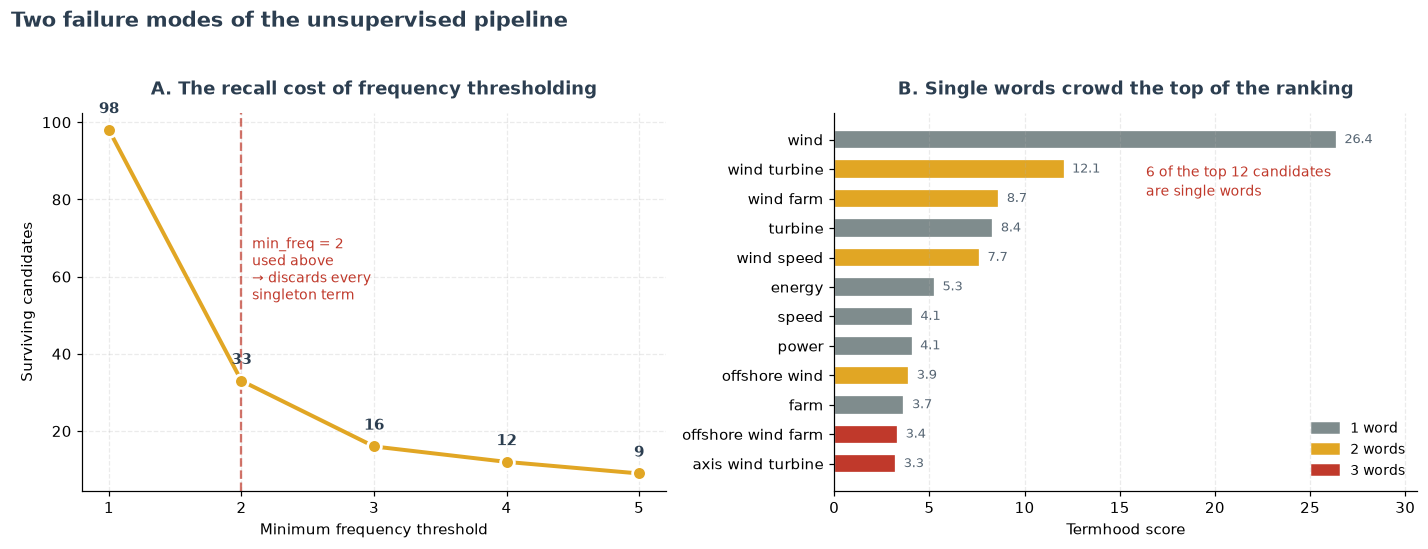

In [12]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "font.family": "DejaVu Sans", "axes.grid": True,
    "grid.alpha": 0.25, "grid.linestyle": "--", "figure.dpi": 110,
})
PALETTE = {1: "#7F8C8D", 2: "#E1A624", 3: "#C0392B"}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8))

# -- panel A: recall cost of thresholding ---------------------------------
ax1.plot(thresholds, surviving, marker="o", markersize=9, lw=2.6,
         color="#E1A624", markeredgecolor="white", markeredgewidth=1.8, zorder=3)
for t, s in zip(thresholds, surviving):
    ax1.annotate(str(s), (t, s), textcoords="offset points", xytext=(0, 11),
                 ha="center", fontsize=9.5, weight="bold", color="#2C3E50")
ax1.axvline(2, color="#C0392B", ls="--", lw=1.5, alpha=0.7)
ax1.text(2.08, max(surviving) * 0.72,
         "min_freq = 2\nused above\n→ discards every\nsingleton term",
         fontsize=9, color="#C0392B", va="top")
ax1.set_xticks(thresholds)
ax1.set_xlabel("Minimum frequency threshold")
ax1.set_ylabel("Surviving candidates")
ax1.set_title("A. The recall cost of frequency thresholding",
              fontsize=11.5, weight="bold", color="#2C3E50", pad=12)

# -- panel B: top ranking coloured by candidate length --------------------
top12 = extract_terms(TECHNICAL_CORPUS, GENERAL_CORPUS, top_n=12)
names = [r["term"] for r in top12]
scores = [r["termhood"] for r in top12]
lens = [r["words"] for r in top12]
ypos = np.arange(len(top12))

ax2.barh(ypos, scores, color=[PALETTE.get(k, "#8E44AD") for k in lens],
         height=0.66, edgecolor="white", linewidth=1.5)
for y, s in zip(ypos, scores):
    ax2.text(s + max(scores) * 0.015, y, f"{s:.1f}", va="center",
             fontsize=8.6, color="#566573")
ax2.set_yticks(ypos)
ax2.set_yticklabels(names, fontsize=9.5)
ax2.invert_yaxis()
ax2.set_xlabel("Termhood score")
ax2.set_xlim(0, max(scores) * 1.16)
ax2.grid(axis="y", visible=False)

n_uni = sum(1 for k in lens if k == 1)
ax2.annotate(f"{n_uni} of the top 12 candidates\nare single words",
             xy=(scores[0] * 0.62, 1.9), fontsize=9, color="#C0392B", linespacing=1.4)

handles = [plt.Rectangle((0, 0), 1, 1, color=PALETTE[k]) for k in (1, 2, 3)]
ax2.legend(handles, ["1 word", "2 words", "3 words"], frameon=False,
           fontsize=9, loc="lower right")
ax2.set_title("B. Single words crowd the top of the ranking",
              fontsize=11.5, weight="bold", color="#2C3E50", pad=12)

fig.suptitle("Two failure modes of the unsupervised pipeline",
             fontsize=13.5, weight="bold", color="#2C3E50", x=0.005, ha="left", y=1.03)
plt.tight_layout()
plt.show()

### 8.3 What the failures teach

| Observation | What it means |
|---|---|
| *wind* ranks #1 overall | Single words swamp multi-word terms — hence the `have_single_word` switch in every production ATE tool |
| *offshore wind*, *axis wind* are fragments | The stopword chunker has no POS grammar, so it cuts phrases in the wrong place |
| *axis wind turbine* should be *horizontal axis wind turbine* | **The nested-term problem, re-emerging in the opposite direction** — C-value demotes over-short fragments but nothing detects an incomplete term |
| *speed*, *power*, *energy* score high | Weirdness is only as good as your contrast corpus, and ours is 200 words |
| *pitch control*, *capacity factor* are missed | `min_freq=2` filters out every singleton — the classic precision/recall trade-off |
| *yaw control* is missed **earlier** | A line break split the bigram, so the linguistic filter never proposed it at all |

<div style="border-left:5px solid #8E44AD; background:#faf5ff;
     border-radius:0 8px 8px 0; padding:14px 20px; margin:16px 0;
     font-family:'Segoe UI',sans-serif; font-size:14px; color:#1f2937;">
<b style="color:#8E44AD;">📚 This is an open research problem, not a bug in our code</b><br>
Tran et al. (2023) list nested terms as an <b>open challenge for Transformer models</b>: current systems &quot;often predict nested shorter terms rather than complete multi-word terms.&quot; The phenomenon Frantzi et al. named in 1998 has outlived every proposed cure, and it appeared unprompted in our 60-line implementation.
</div>

<a id="s9"></a>
<div style="
    background: linear-gradient(90deg, #0f172a 0%, #2563eb 55%, #0f172a 100%);
    border-radius: 12px;
    padding: 18px 28px;
    margin: 34px 0 6px 0;
    box-shadow: 0 4px 14px rgba(0,0,0,0.25);
">
<h2 style="margin:0; font-size:23px; font-weight:800; color:#f1f5f9;
           font-family:'Segoe UI',sans-serif; letter-spacing:0.3px;">
9 &nbsp;Evaluation and the ACTER Benchmark</h2>
<p style="margin:8px 0 0 0; font-size:14px; color:#94a3b8; font-family:'Segoe UI',sans-serif;">Before 2020, ATE results were effectively incomparable.</p>
</div>

<p style="text-align:right; margin-top:6px;"><a href="#toc"
   style="color:#2563eb; text-decoration:none; font-size:13px;">back to top ↑</a></p>

Each research group evaluated on its own corpus, with its own operational definition
of "term." **TermEval 2020** changed this by releasing **ACTER** — the *Annotated Corpora
for Term Extraction Research* — with the explicit aim of providing "a large, transparent,
qualitatively annotated, and diverse dataset to the ATE research community"
(Rigouts Terryn et al., 2020).

| Domain | Code | Files | Sentences | Tokens | Role |
|---|:---:|:---:|:---:|:---:|---|
| Corruption | `corp` | 12 | 1 977–2 002 | 52 847–61 107 | Training (parallel corpus) |
| Equitation | `equi` | 34–78 | 2 809–3 669 | 60 119–63 870 | Training (comparable) |
| Wind energy | `wind` | 2–8 | 3 356–6 638 | 58 684–69 759 | Training / validation |
| **Heart failure** | `htfl` | 174–210 | 2 177–2 880 | 57 204–57 899 | **Held-out test set** |

<p style="font-size:12.5px; color:#64748b; font-style:italic;">
Table 4 — ACTER v1.5 (Rigouts Terryn, Hoste &amp; Lefever, 2019); three languages
(English, French, Dutch), ranges span languages. Source: github.com/AylaRT/ACTER</p>

Two design decisions make ACTER effective. The **heart-failure domain is held out
entirely**, so reported F1 measures cross-domain generalisation rather than in-domain
fitting. And the corpus is **multilingual by construction**, enabling the cross-lingual
transfer experiments that dominate recent work.

Evaluation uses standard metrics against the gold annotation:

$$
\text{Precision} = \frac{TP}{TP + FP}
\qquad
\text{Recall} = \frac{TP}{TP + FN}
\qquad
F_1 = \frac{2 \cdot P \cdot R}{P + R}
$$

<div style="border-left:5px solid #2563eb; background:#eff6ff;
     border-radius:0 8px 8px 0; padding:14px 20px; margin:16px 0;
     font-family:'Segoe UI',sans-serif; font-size:14px; color:#1f2937;">
<b style="color:#2563eb;">📌 A caveat about our 70%</b><br>
The precision figure we computed in section 7 is <b>not</b> comparable to published ACTER scores. Ours is precision@10 on a 250-word toy corpus, judged by one person. Published systems report precision, recall and F1 over a fully annotated held-out domain. Treat our number as a sanity check, never as a benchmark result.
</div>

<a id="s10"></a>
<div style="
    background: linear-gradient(90deg, #0f172a 0%, #2563eb 55%, #0f172a 100%);
    border-radius: 12px;
    padding: 18px 28px;
    margin: 34px 0 6px 0;
    box-shadow: 0 4px 14px rgba(0,0,0,0.25);
">
<h2 style="margin:0; font-size:23px; font-weight:800; color:#f1f5f9;
           font-family:'Segoe UI',sans-serif; letter-spacing:0.3px;">
10 &nbsp;The State of the Art</h2>
<p style="margin:8px 0 0 0; font-size:14px; color:#94a3b8; font-family:'Segoe UI',sans-serif;">Feature engineering → Transformers → large language models.</p>
</div>

<p style="text-align:right; margin-top:6px;"><a href="#toc"
   style="color:#2563eb; text-decoration:none; font-size:13px;">back to top ↑</a></p>

### 10.1 Neural models displaced feature engineering

Tran et al. (2023) surveyed 112 papers and reported comparative results on the ACTER
held-out test set. Ranges span three languages and two annotation settings.

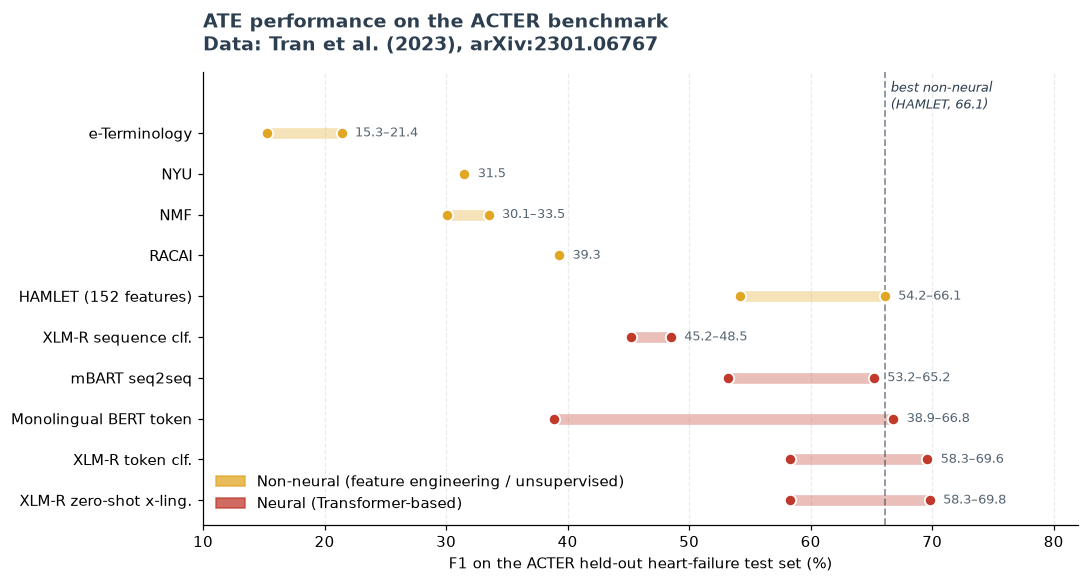

In [13]:
acter = pd.DataFrame([
    ("e-Terminology",             "non-neural", 15.3, 21.4),
    ("NYU",                       "non-neural", 31.5, 31.5),
    ("NMF",                       "non-neural", 30.1, 33.5),
    ("RACAI",                     "non-neural", 39.3, 39.3),
    ("HAMLET (152 features)",     "non-neural", 54.2, 66.1),
    ("XLM-R sequence clf.",       "neural",     45.2, 48.5),
    ("mBART seq2seq",             "neural",     53.2, 65.2),
    ("Monolingual BERT token",    "neural",     38.9, 66.8),
    ("XLM-R token clf.",          "neural",     58.3, 69.6),
    ("XLM-R zero-shot x-ling.",   "neural",     58.3, 69.8),
], columns=["system", "family", "F1_low", "F1_high"])

fig, ax = plt.subplots(figsize=(10, 5.4))
for i, r in acter.iterrows():
    color = "#C0392B" if r.family == "neural" else "#E1A624"
    if r.F1_high > r.F1_low:
        ax.plot([r.F1_low, r.F1_high], [i, i], lw=7, color=color, alpha=0.32,
                solid_capstyle="round", zorder=2)
    ax.scatter([r.F1_low, r.F1_high], [i, i], s=55, color=color, zorder=3,
               edgecolor="white", linewidth=1.2)
    label = f"{r.F1_low:.1f}" if r.F1_high == r.F1_low else f"{r.F1_low:.1f}–{r.F1_high:.1f}"
    ax.text(r.F1_high + 1.1, i, label, va="center", fontsize=8.8, color="#566573")

ax.axvline(66.1, color="#2C3E50", ls="--", lw=1.2, alpha=0.55)
ax.text(66.6, -0.9, "best non-neural\n(HAMLET, 66.1)", fontsize=8.6,
        color="#2C3E50", style="italic", va="center")
ax.set_yticks(range(len(acter)))
ax.set_yticklabels(acter["system"], fontsize=9.8)
ax.set_ylim(len(acter) - 0.4, -1.5)
ax.set_xlim(10, 82)
ax.set_xlabel("F1 on the ACTER held-out heart-failure test set (%)")
ax.grid(axis="y", visible=False)
handles = [plt.Rectangle((0, 0), 1, 1, color=c, alpha=0.75) for c in ("#E1A624", "#C0392B")]
ax.legend(handles, ["Non-neural (feature engineering / unsupervised)",
                    "Neural (Transformer-based)"],
          frameon=False, fontsize=9.5, loc="lower left")
ax.set_title("ATE performance on the ACTER benchmark\nData: Tran et al. (2023), arXiv:2301.06767",
             fontsize=12.5, weight="bold", loc="left", color="#2C3E50", pad=14)
plt.tight_layout()
plt.show()

Three conclusions follow:

1. **Neural models outperform feature engineering by a large margin.** HAMLET — a Random
   Forest over 152 hand-designed features, the strongest non-neural system — reaches
   54.2–66.1 F1. The XLM-R token classifier reaches 58.3–69.6.
2. **Task framing matters more than model size.** The same XLM-R encoder scores 45.2–48.5
   as a *sequence classifier* and 58.3–69.6 as a *token classifier*. A twenty-point gap
   from problem formulation alone.
3. **Zero-shot cross-lingual transfer is nearly free** — 58.3–69.8 F1 on an unseen
   language, matching the monolingual result.

### 10.2 Where LLMs win, and where they do not

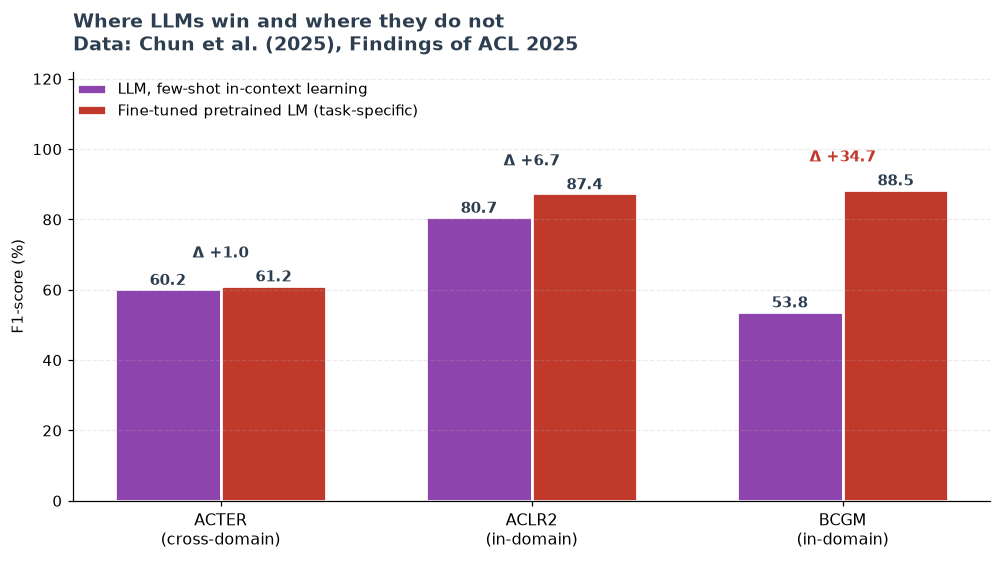

In [14]:
llm = pd.DataFrame({
    "benchmark": ["ACTER\n(cross-domain)", "ACLR2\n(in-domain)", "BCGM\n(in-domain)"],
    "LLM few-shot": [60.2, 80.7, 53.8],
    "Fine-tuned PLM": [61.2, 87.4, 88.5],
})

x = np.arange(len(llm)); w = 0.34
fig, ax = plt.subplots(figsize=(9.2, 5.2))
b1 = ax.bar(x - w/2, llm["LLM few-shot"], w, color="#8E44AD",
            edgecolor="white", linewidth=1.8, label="LLM, few-shot in-context learning")
b2 = ax.bar(x + w/2, llm["Fine-tuned PLM"], w, color="#C0392B",
            edgecolor="white", linewidth=1.8, label="Fine-tuned pretrained LM (task-specific)")
for bars in (b1, b2):
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1.2, f"{b.get_height():.1f}",
                ha="center", fontsize=10, weight="bold", color="#2C3E50")
for i, (a, p) in enumerate(zip(llm["LLM few-shot"], llm["Fine-tuned PLM"])):
    gap = p - a
    ax.annotate(f"Δ {gap:+.1f}", xy=(i, max(a, p) + 8), ha="center", fontsize=10,
                weight="bold", color="#C0392B" if gap > 10 else "#2C3E50")
ax.set_xticks(x); ax.set_xticklabels(llm["benchmark"], fontsize=10.5)
ax.set_ylabel("F1-score (%)"); ax.set_ylim(0, 122)
ax.legend(frameon=False, fontsize=9.5, loc="upper left", bbox_to_anchor=(-0.01, 1.005))
ax.grid(axis="x", visible=False)
ax.set_title("Where LLMs win and where they do not\nData: Chun et al. (2025), Findings of ACL 2025",
             fontsize=12.5, weight="bold", loc="left", color="#2C3E50", pad=14)
plt.tight_layout()
plt.show()

Two papers answer complementary questions, and neither alone tells the full story:

- **Banerjee et al. (2024)** found GPT-3.5-Turbo few-shot in-context learning
  **outperforms** a fine-tuned BERT-sized model and unsupervised count-based methods.
  They also quantified **prompt sensitivity** across templates — an unusually honest
  contribution.
- **Chun et al. (2025)** found fine-tuned encoders still win decisively **in-domain**:
  88.5 vs. 53.8 F1 on the BioCreAtIvE gene-mention benchmark.

<div style="border-left:5px solid #5BAD8D; background:#ecfdf5;
     border-radius:0 8px 8px 0; padding:14px 20px; margin:16px 0;
     font-family:'Segoe UI',sans-serif; font-size:14px; color:#1f2937;">
<b style="color:#5BAD8D;">🔑 The decision rule</b><br>
<b>LLMs win when labelled data is scarce. Fine-tuned encoders win when it is not.</b> These findings are not in conflict — they answer different questions.
</div>

### 10.3 The counterintuitive part: retrieve by syntax, not semantics

Chun et al.'s methodological contribution is how few-shot demonstrations are *selected*.
The standard approach retrieves semantically similar examples; they argue this fails
across domains, since when "cross-domain scenarios lack gold term overlap, retrieving
semantically similar sentences may not provide useful guidance."

Their alternative retrieves examples with structurally similar **constituency parse
trees**. The intuition: a term's meaning does not transfer across domains, but its shape
does. *horizontal axis wind turbine* and *chronic heart failure treatment* share no
semantics whatsoever, yet share a syntactic skeleton — and that skeleton is what teaches
the model where term boundaries fall.

To diagnose what the demonstrations actually contribute they introduce the
**Term Overlap Ratio**:

$$
\text{TOR} = \frac{1}{N_q}\sum_{q} \frac{\lvert G_q \cap R_q \rvert}{\lvert G_q \rvert}
$$

where $G_q$ are the gold terms of query $q$ and $R_q$ the terms appearing in its retrieved
demonstrations. Three results deserve wider circulation:

1. **Syntactic retrieval achieves TOR = 0 cross-domain** — the demonstrations contain
   *none* of the gold terms — and remains competitive regardless.
2. **Semantic retrieval shows a *negative* correlation** between term overlap and F1
   cross-domain, because of "words functioning as domain-specific terms in one field but
   generic in others." The intuitive move measurably hurts.
3. **An unlexicalized PCFG parser beats neural CRF+RoBERTa parsers** for retrieval —
   isolating syntax *from* semantics is what makes the method work.

<a id="s11"></a>
<div style="
    background: linear-gradient(90deg, #0f172a 0%, #2563eb 55%, #0f172a 100%);
    border-radius: 12px;
    padding: 18px 28px;
    margin: 34px 0 6px 0;
    box-shadow: 0 4px 14px rgba(0,0,0,0.25);
">
<h2 style="margin:0; font-size:23px; font-weight:800; color:#f1f5f9;
           font-family:'Segoe UI',sans-serif; letter-spacing:0.3px;">
11 &nbsp;Choosing a Method</h2>
<p style="margin:8px 0 0 0; font-size:14px; color:#94a3b8; font-family:'Segoe UI',sans-serif;">A decision guide.</p>
</div>

<p style="text-align:right; margin-top:6px;"><a href="#toc"
   style="color:#2563eb; text-decoration:none; font-size:13px;">back to top ↑</a></p>

In [15]:
guide = pd.DataFrame([
    ("Unsupervised statistical", "C-value, weirdness (PyATE)", "None",
     "≈15–39", "No annotation exists; interpretability required"),
    ("Feature-engineered supervised", "HAMLET (152 features)", "In-domain, large",
     "54.2–66.1", "Annotated data exists; features must be auditable"),
    ("Transformer token classification", "XLM-R token classifier", "In-domain, large",
     "58.3–69.6", "Best accuracy and annotation is available"),
    ("Cross-lingual zero-shot", "XLM-R, zero-shot transfer", "Other-language only",
     "58.3–69.8", "Target language has no annotated data"),
    ("LLM in-context learning", "GPT-3.5 / Llama-3.1 few-shot", "A handful of examples",
     "≈60 (cross-domain)", "Few-shot regime, or a new domain with no data"),
], columns=["method family", "representative system", "labelled data",
            "reported F1 (ACTER)", "use when"])

guide.style.set_properties(**{"text-align": "left", "font-size": "13px"}) \
     .set_table_styles([{"selector": "th",
                         "props": [("background-color", "#0f172a"),
                                   ("color", "white"),
                                   ("text-align", "left"),
                                   ("font-size", "13px")]}]) \
     .hide(axis="index")

method family,representative system,labelled data,reported F1 (ACTER),use when
Unsupervised statistical,"C-value, weirdness (PyATE)",None,≈15–39,No annotation exists; interpretability required
Feature-engineered supervised,HAMLET (152 features),"In-domain, large",54.2–66.1,Annotated data exists; features must be auditable
Transformer token classification,XLM-R token classifier,"In-domain, large",58.3–69.6,Best accuracy and annotation is available
Cross-lingual zero-shot,"XLM-R, zero-shot transfer",Other-language only,58.3–69.8,Target language has no annotated data
LLM in-context learning,GPT-3.5 / Llama-3.1 few-shot,A handful of examples,≈60 (cross-domain),"Few-shot regime, or a new domain with no data"


### 11.1 In practice: PyATE

For the classical algorithms you do not need to write your own. **PyATE** implements
C-value, Basic, Combo Basic, Weirdness and Term Extractor over spaCy POS tagging:

```python
!pip install pyate
!python -m spacy download en_core_web_sm
```

```python
from pyate import combo_basic

print(combo_basic(TECHNICAL_CORPUS).sort_values(ascending=False).head(10))
```

```python
import spacy
from pyate.term_extraction_pipeline import TermExtractionPipeline

nlp = spacy.load("en_core_web_sm")
nlp.add_pipe("combo_basic")
doc = nlp(TECHNICAL_CORPUS)
print(doc._.combo_basic.sort_values(ascending=False).head(5))
```

<div style="border-left:5px solid #E1A624; background:#fffbeb;
     border-radius:0 8px 8px 0; padding:14px 20px; margin:16px 0;
     font-family:'Segoe UI',sans-serif; font-size:14px; color:#1f2937;">
<b style="color:#E1A624;">⚠️ Two caveats before you ship this</b><br>
<b>1.</b> PyATE ships a supervised spaCy model, <code>en_acl_terms_sm</code>, reporting 94.71% F-score — but trained on ACL computer-science terminology and, per the library's own documentation, not validated on other domains. Given that cross-domain ACTER results cluster in the 50–70 F1 range, do not read that figure as general-purpose performance.<br><b>2.</b> PyATE targets older spaCy releases. Pin your version or use an isolated environment.
</div>

### 11.2 Open problems

- **Nested terms remain unsolved.** Diagnosed in 1998, still listed as an open challenge
  for Transformers in 2023, and visible in our own output in section 8.
- **Annotation does not scale.** Building domain-specific annotated corpora is
  "error-prone, labor-intensive, time-consuming, and subjective" — which is what makes
  zero-shot and few-shot results consequential rather than merely interesting.
- **Ensembling is under-explored.** Tran et al. (2023) recommend combining pretrained
  language models with the classical statistical measures rather than treating the
  paradigms as competitors. C-value contributes an inductive bias about nested structure
  that no Transformer has yet learned reliably.

<a id="s12"></a>
<div style="
    background: linear-gradient(90deg, #0f172a 0%, #2563eb 55%, #0f172a 100%);
    border-radius: 12px;
    padding: 18px 28px;
    margin: 34px 0 6px 0;
    box-shadow: 0 4px 14px rgba(0,0,0,0.25);
">
<h2 style="margin:0; font-size:23px; font-weight:800; color:#f1f5f9;
           font-family:'Segoe UI',sans-serif; letter-spacing:0.3px;">
12 &nbsp;References</h2>
<p style="margin:8px 0 0 0; font-size:14px; color:#94a3b8; font-family:'Segoe UI',sans-serif;">Every paper cited in this notebook.</p>
</div>

<p style="text-align:right; margin-top:6px;"><a href="#toc"
   style="color:#2563eb; text-decoration:none; font-size:13px;">back to top ↑</a></p>

Ahmad, K., Gillam, L., & Tostevin, L. *Weirdness indexing for logical document
extrapolation and retrieval.* Proceedings of TREC-8.

Banerjee, S., Chakravarthi, B. R., & McCrae, J. P. (2024). *Large Language Models for
Few-Shot Automatic Term Extraction.* NLDB 2024, LNCS vol. 14762. Springer.
[doi:10.1007/978-3-031-70239-6_10](https://doi.org/10.1007/978-3-031-70239-6_10)

Blandón Andrade, J. C., Medina Otálvaro, C. M., Zapata Jaramillo, C. M., & Morales Ríos, A.
(2026). *Approaches, Tools, Algorithms, and Methods for Automatic Term Extraction: A
Systematic Literature Mapping.*
[doi:10.1177/18758967251392652](https://doi.org/10.1177/18758967251392652)

Chun, Y., Kim, M., Kim, D., Park, C., & Lim, H. (2025). *Enhancing Automatic Term
Extraction with Large Language Models via Syntactic Retrieval.* Findings of ACL 2025.
[aclanthology.org/2025.findings-acl.516](https://aclanthology.org/2025.findings-acl.516/) ·
[arXiv:2506.21222](https://arxiv.org/abs/2506.21222)

Frantzi, K., Ananiadou, S., & Mima, H. (2000). *Automatic recognition of multi-word terms:
the C-value/NC-value method.* International Journal on Digital Libraries, 3(2), 115–130.
[doi:10.1007/s007999900023](https://doi.org/10.1007/s007999900023)

Lu, K. *PyATE: Python Automated Term Extraction.*
[github.com/kevinlu1248/pyate](https://github.com/kevinlu1248/pyate)

Rigouts Terryn, A., Hoste, V., & Lefever, E. (2019). *In no uncertain terms: a dataset for
monolingual and multilingual automatic term extraction from comparable corpora.* Language
Resources and Evaluation, 54(2), 385–418.
[doi:10.1007/s10579-019-09453-9](https://doi.org/10.1007/s10579-019-09453-9)

Rigouts Terryn, A., Hoste, V., Drouin, P., & Lefever, E. (2020). *TermEval 2020: Shared Task
on Automatic Term Extraction Using the ACTER Dataset.* COMPUTERM 2020 @ LREC, 85–94.
[aclanthology.org/2020.computerm-1.12](https://aclanthology.org/2020.computerm-1.12/)

Tran, H. T. H., Martinc, M., Caporusso, J., Doucet, A., & Pollak, S. (2023). *The Recent
Advances in Automatic Term Extraction: A survey.*
[arXiv:2301.06767](https://arxiv.org/abs/2301.06767)

Tran, H. T. H., Martinc, M., Caporusso, J., Delaunay, J., Doucet, A., & Pollak, S. (2026).
*Recent Advances in Automatic Term Extraction: A Comprehensive Survey.* ACM Computing
Surveys. [doi:10.1145/3787584](https://doi.org/10.1145/3787584)

Xu, K., Feng, Y., Li, Q., Dong, Z., & Wei, J. (2025). *Survey on terminology extraction from
texts.* Journal of Big Data.
[doi:10.1186/s40537-025-01077-x](https://doi.org/10.1186/s40537-025-01077-x)

**Dataset:** ACTER — [github.com/AylaRT/ACTER](https://github.com/AylaRT/ACTER) (CC BY-NC-SA 4.0)

<div style="background:linear-gradient(135deg,#0f172a 0%,#0f4c75 100%);
     border-radius:14px; padding:30px 36px; margin-top:34px; text-align:center;
     font-family:'Segoe UI',sans-serif; box-shadow:0 6px 24px rgba(0,0,0,0.3);">
  <h3 style="color:#f1f5f9; margin:0 0 10px 0; font-size:20px;">Thanks for reading</h3>
  <p style="color:#94a3b8; margin:0 0 18px 0; font-size:14px;">
    If this was useful, an upvote helps other people find it.</p>
  <a href="https://www.linkedin.com/in/huseyincenik/" style="color:#93c5fd; text-decoration:none; font-size:14px;">
    LinkedIn</a>
  <span style="color:#334155;">&nbsp;·&nbsp;</span>
  <a href="#toc" style="color:#93c5fd; text-decoration:none; font-size:14px;">
    Back to contents</a>
</div>